## 프로젝트: 한영 번역기 (Seq2seq with Attention)

한영 병렬 코퍼스를 활용하여 한국어를 영어로 번역하는 **Attention 기반 Seq2seq 모델**을 설계하고 학습한다.


### 목차 (Table of Contents)

1. [환경 설정 및 라이브러리 점검](#0.-환경-설정-및-라이브러리-점검)
2. [시스템 구조 (System Architecture)](#시스템-구조)
3. [데이터 확보 및 정제](#1.-데이터-확보-(Step-1),-데이터-정제-(Step-2))
    - [데이터 로드 및 중복 제거](#데이터-로드-및-중복-제거)
    - [데이터 길이 분석 (EDA)](#데이터-길이-분석-(EDA))
    - [노이즈 체크 및 이상치 확인](#노이즈-체크-및-이상치-확인)
4. [데이터 토큰화 (Step 3)](#3.-데이터-토큰화-(Step-3))
5. [모델 설계 (Step 4)](#4.-모델-설계-(Step-4))
6. [모델 훈련 및 결과 제출 (Step 5)](#5.-모델-훈련-및-결과-제출-(Step-5))
7. [실험 실행](#6.-실험-실행)
    - [실험 1 (Vocab 10000)](#실험-1-(Vocab-10000))
    - [실험 2 (Vocab 12000)](#실험-2-(Vocab-12000))


### 요구 사항

#### 0. 환경 설정 및 라이브러리 점검

- [x] 본격적인 데이터 처리 이전에 사용할 주요 라이브러리의 버전을 확인합니다.

- **Target Libraries:** `pandas`, `torch`, `matplotlib`

---

#### 1. 데이터 확보 (Step 1)

학습에 필요한 한영 병렬 데이터를 다운로드합니다.

- [x] **데이터셋:** `korean-english-park.train.tar.gz`
- [x] **출처:** [jungyeul/korean-parallel-corpora](https://github.com/jungyeul/korean-parallel-corpora)

---

#### 2. 데이터 정제 (Step 2)

데이터의 품질을 높이기 위해 다음 과정을 거칩니다.

1. [x] **중복 제거:** `set` 자료형을 활용하여 중복 데이터를 제거합니다. (병렬 쌍이 어긋나지 않도록 주의)
2. [x] **데이터 저장:** 정제된 데이터는 `cleaned_corpus`에 저장합니다.
3. [x] **전처리 함수 재정의:**
    - 한글에 특화된 정규 표현식을 추가하여 `preprocessing()` 함수를 업데이트합니다.
    - **영어(Target):** 문장 시작과 끝에 `<start>`, `<end>` 토큰을 추가하고 `split()`으로 토큰화합니다.
    - **한국어(Source):** `KoNLPy`의 `Mecab` 클래스를 사용하여 형태소 분석 및 토큰화를 진행합니다.
4. [x] **데이터 선별:** 학습 효율을 위해 토큰 길이가 **40 이하**인 데이터만 선별하여 `kor_corpus`와 `eng_corpus`를 구축합니다.

---

#### 3. 데이터 토큰화 (Step 3)

정제된 코퍼스를 모델이 이해할 수 있는 텐서 형태로 변환합니다.

- [X] `tokenize()` 함수를 사용하여 데이터를 텐서화하고 각각의 Tokenizer를 생성합니다.
- [ ] **단어 사전 크기:** 최소 **10,000개 이상**으로 설정하며 실험을 통해 최적값을 찾습니다.
- **참고:** 데이터 규모를 고려하여 별도의 검증 데이터(Validation Set) 분리 없이 전체를 훈련에 사용합니다.

---

#### 4. 모델 설계 (Step 4)

한국어를 영어로 번역하는 **Attention 기반 Seq2seq** 구조를 설계합니다.

- [X] **구조:** Encoder - Decoder (with Attention Mechanism)
- [ ] **하이퍼파라미터: `Embedding Size`와 `Hidden Size`는 실험을 통해 최적화합니다.**

---

#### 5. 모델 훈련 및 결과 제출 (Step 5)

모델을 학습시키고 번역 성능을 확인합니다.

- [x] **훈련 방식:** 기존 훈련 코드를 사용하되, `eval_step()` 과정은 생략합니다.
- [x] **성능 확인:** 매 스텝마다 아래 예문에 대한 번역 결과를 생성합니다.
- [x] **시각화:** `Attention Map`을 시각화하여 모델이 단어 간의 관계를 어떻게 파악하는지 확인합니다.
- [ ] Implement BLEU score evaluation

#### 6. 테스트 예문 (Evaluation)

| **ID** | **한국어 예문 (Input)** | **기대 출력 (Example)** |
| --- | --- | --- |
| **K1** | 오바마는 대통령이다. | obama is the president . `<end>` |
| **K2** | 시민들은 도시 속에 산다. | people are victims of the city . `<end>` |
| **K3** | 커피는 필요 없다. | the price is not enough . `<end>` |
| **K4** | 일곱 명의 사망자가 발생했다. | seven people have died . `<end>` |


### 시스템 구조

#### Class Diagram

```mermaid
classDiagram
    class DataHandler {
        +ko_path: str
        +en_path: str
        +pecab: PeCab
        +download_data()
        +extract_data()
        +load_raw_data(): List
        +preprocess_sentence(sentence: str): str
        +tokenize_manual(corpus: List)
        +sequences_to_tensor(sentences: List, tokenizer: Tokenizer): Tensor
    }
    class Tokenizer {
        +vocab_size: int
        +word2idx: dict
        +idx2word: dict
        +build_vocab(corpus: List)
        +encode(sentence: List): List
        +decode(ids: List): List
    }
    class Seq2SeqAttention {
        +encoder: Encoder
        +decoder: Decoder
        +device: device
        +forward(src, trg, max_len)
    }
    class NMTManager {
        +model: nn.Module
        +optimizer: Optimizer
        +criterion: nn.Module
        +device: device
        +data_handler: DataHandler
        +train(loader, epochs, kor_tok, eng_tok)
        +translate(sentence, kor_tok, eng_tok)
        +visualize_attention(sentence, kor_tok, eng_tok)
    }
    class Encoder {
        +embedding: nn.Embedding
        +rnn: nn.GRU
        +forward(src)
    }
    class Decoder {
        +attention: BahdanauAttention
        +embedding: nn.Embedding
        +rnn: nn.GRU
        +fc_out: nn.Linear
        +forward(input, hidden, encoder_outputs)
    }
    class BahdanauAttention {
        +W1: nn.Linear
        +W2: nn.Linear
        +v: nn.Linear
        +forward(hidden, encoder_outputs)
    }

    NMTManager --> Seq2SeqAttention : manages
    NMTManager --> DataHandler : uses
    Seq2SeqAttention --> Encoder : contains
    Seq2SeqAttention --> Decoder : contains
    Decoder --> BahdanauAttention : uses
    DataHandler ..> Tokenizer : uses during tensorization
```


#### Sequence Diagram


```mermaid
sequenceDiagram
    participant U as Experiment/User
    participant DH as DataHandler
    participant T as Tokenizer
    participant NMT as NMTManager
    Note over U, DH: 1. 데이터 로드 및 전처리
    U->>DH: load_raw_data() 
    Note right of DH: 중복 제거 및 데이터 병합
    DH-->>U: cleaned_corpus

    U->>DH: tokenize_manual(cleaned_corpus)
    Note right of DH: 형태소 분석 (PeCab) 및 캐싱
    DH-->>U: kor_tokens, eng_tokens (cached)

    U->>T: build_vocab(kor_tokens / eng_tokens)
    Note right of T: 단어 사전(Vocab) 생성

    U->>DH: sequences_to_tensor(tokens, T)
    Note right of DH: Padding & Truncating (Max Len: 40)
    DH-->>U: src_tensor, trg_tensor

    Note over U, NMT: 2. 모델 학습 (Teacher Forcing 사용)
    U->>NMT: train(dataloader, epochs, kor_tok, eng_tok)
    loop Epochs
        loop Batches
            NMT->>M: forward(src, trg[:-1])
            M-->>NMT: output
            NMT->>NMT: loss.backward() & optimizer.step()
        end
        Note over NMT: 훈련 데이터 샘플 평가 (Greedy Decoding)
    end

    Note over U, NMT: 3. 번역 테스트 및 결과 시각화
    U->>NMT: visualize_attention("오바마는 대통령이다.", kor_tok, eng_tok)
    NMT->>M: forward(input_tensor, max_len)
    M-->>NMT: translation, attentions
    NMT-->>U: Attention Map 시각화
```

### 0. 환경 설정 및 라이브러리 점검

In [36]:
# !apt-get update 
# !apt-get install -y fonts-nanum

# pip install sentencepiece pecab nltk

In [37]:
from typing import List, Tuple, Dict, Any, Optional, Union
import os
import re
import urllib.request
import tarfile
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pecab import PeCab

print(torch.__version__)

2.7.1+cu118


### 1. 데이터 확보 (Step 1), 데이터 정제 (Step 2)

데이터의 품질을 높이기 위해 중복 제거 및 전처리 과정을 거칩니다.

In [38]:
class DataHandler:
    def __init__(self, ko_path: str, en_path: str) -> None:
        self.ko_path = ko_path
        self.en_path = en_path
        self.pecab = PeCab()
        self.data_url = ("https://github.com/jungyeul/korean-parallel-corpora/raw/master/"
                         "korean-english-news-v1/korean-english-park.train.tar.gz")
        self.data_filename = "korean-english-park.train.tar.gz"

    def download_data(self) -> None:
        if not os.path.exists(self.data_filename):
            print(f"Downloading {self.data_filename}...")
            urllib.request.urlretrieve(self.data_url, self.data_filename)

    def extract_data(self) -> None:
        print(f"Extracting {self.data_filename}...")
        with tarfile.open(self.data_filename, "r:gz") as tar:
            tar.extractall()

    def load_raw_data(self) -> List[Tuple[str, str]]:
        if not os.path.exists(self.ko_path) or not os.path.exists(self.en_path):
            self.download_data()
            self.extract_data()

        with open(self.ko_path, "r", encoding="utf-8") as f: ko_corpus = f.read().splitlines()
        with open(self.en_path, "r", encoding="utf-8") as f: en_corpus = f.read().splitlines()
            
        cleaned_corpus = list(set(zip(ko_corpus, en_corpus)))
        return cleaned_corpus

    def preprocess_sentence(self, sentence: str) -> str:
        sentence = sentence.lower().strip()
        sentence = re.sub(r"([?.!,])", r" \1 ", sentence)
        sentence = re.sub(r'[" "]+', " ", sentence)
        sentence = re.sub(r"[^ㄱ-ㅎㅏ-ㅣ가-힣a-zA-Z0-9?.!,]+", " ", sentence)
        return sentence.strip()

    def tokenize_manual(self, corpus: List[Tuple[str, str]], max_len: int = 40, cache_file: str = "tokens_manual.pkl") -> Tuple[List[List[str]], List[List[str]]]:
        if os.path.exists(cache_file):
            print(f"Loading cached tokens from {cache_file}...")
            with open(cache_file, "rb") as f:
                return pickle.load(f)

        kor_corpus = []
        eng_corpus = []
        for ko, en in tqdm(corpus, desc="Tokenizing"):
            ko_pre = self.preprocess_sentence(ko)
            en_pre = self.preprocess_sentence(en)
            
            ko_tokens = self.pecab.morphs(ko_pre)
            en_tokens = ["<start>"] + en_pre.split() + ["<end>"]
            
            if len(ko_tokens) <= max_len and len(en_tokens) <= max_len:
                kor_corpus.append(ko_tokens)
                eng_corpus.append(en_tokens)

        print(f"Saving tokenized results to {cache_file}...")
        with open(cache_file, "wb") as f:
            pickle.dump((kor_corpus, eng_corpus), f)

        return kor_corpus, eng_corpus

    #  sequences_to_tensor() : 문장(토큰들) ->PyTorch 텐서(ids 목록)으로 변환
    def sequences_to_tensor(self, sentences: List[List[str]], tokenizer: "Tokenizer", max_len: int = 40) -> torch.Tensor:
        tensor = []
        for tokens in sentences:
            ids = tokenizer.encode(tokens)
            if len(ids) < max_len:
                ids += [0] * (max_len - len(ids))
            else:
                ids = ids[:max_len]
            tensor.append(ids)
        return torch.tensor(tensor)


#### 데이터 로드 및 중복 제거

In [39]:
import pandas as pd
from collections import Counter

handler = DataHandler(
    ko_path="korean-english-park.train.ko",
    en_path="korean-english-park.train.en"
)
raw_data = handler.load_raw_data()
df = pd.DataFrame(raw_data, columns=["ko", "en"])

print(f"전체 데이터 개수: {len(df)}")
df.drop_duplicates(inplace=True)
print(f"중복 제거 후 데이터 개수: {len(df)}")
df.head()

전체 데이터 개수: 78968
중복 제거 후 데이터 개수: 78968


,ko,en
0,그러나 (북부 노동자의) 즉각적인 임금 삭감을 통해 외국 자동차업체들과 동등한 조건...,But the big rub for auto workers is Republican...
1,이들은 오랜 친구와 헤어지듯 서로 부둥켜안고 이별을 아쉬워했다.,They embraced and patted each others' backs as...
2,미켈슨은 “운이 좋았다”며 “3타만에 홀에 넣어 나도 놀랐다”고 웃으며 말했다.,"""I'm as surprised as anybody I was able to mak..."
3,교황의 특별전세기인 셰퍼드 1기가 사람들의 환영을 받으며 매릴랜드 주 앤드루스 공군...,"The papal plane, Shepherd 1, touched down at A..."
4,"이라크 군은 14일, 바스라에서 소탕작전을 벌이던 중 버틀러 기자를 구출했으며 그를...","Butler, who is British, was freed Monday by ch..."


#### 데이터 길이 분석 (EDA)

한국어 문장 길이 통계:
count    78968.000000
mean        63.927477
std         27.627125
min          1.000000
25%         44.000000
50%         62.000000
75%         81.000000
max        377.000000
Name: ko_len, dtype: float64

영어 문장 길이 통계:
count    78968.000000
mean       133.883155
std         60.891960
min          1.000000
25%         89.000000
50%        128.000000
75%        173.000000
max        605.000000
Name: en_len, dtype: float64


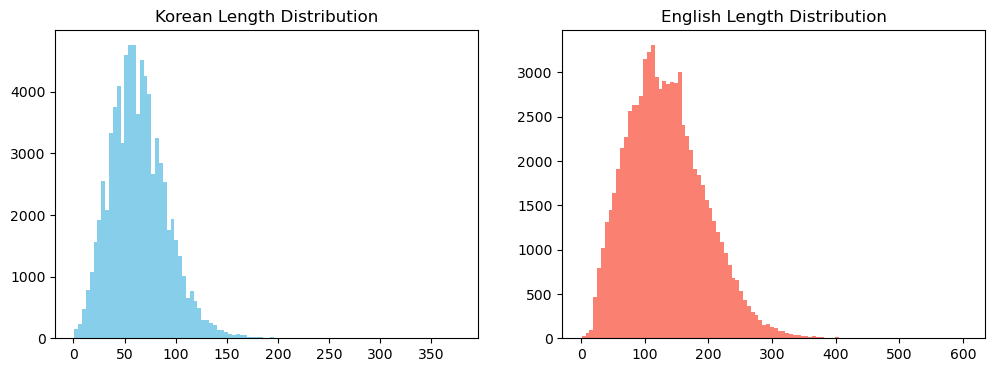

In [40]:
df["ko_len"] = df["ko"].apply(len)
df["en_len"] = df["en"].apply(len)

print("한국어 문장 길이 통계:")
print(df["ko_len"].describe())
print("\n영어 문장 길이 통계:")
print(df["en_len"].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df["ko_len"], bins=100, color='skyblue')
plt.title("Korean Length Distribution")
plt.subplot(1, 2, 2)
plt.hist(df["en_len"], bins=100, color='salmon')
plt.title("English Length Distribution")
plt.show()

#### 노이즈 체크 및 이상치 확인

In [41]:
def check_noise(df: pd.DataFrame) -> None:
    if len(df) == 0:
        print("데이터가 비어 있습니다.")
        return

    df_clean = df.copy()
    df_clean["ko"] = df_clean["ko"].fillna("").astype(str)
    
    en_in_ko = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(r'[a-zA-Z]', x)))]
    print(f"영어 포함 한국어 문장: {len(en_in_ko)} ({len(en_in_ko)/len(df_clean)*100:.2f}%)")
    
    hanja_regex = r'[\u4e00-\u9fff]'
    hanja_in_ko = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(hanja_regex, x)))]
    print(f"한자 포함 한국어 문장: {len(hanja_in_ko)} ({len(hanja_in_ko)/len(df_clean)*100:.2f}%)")
    
    spec_chars = df_clean[df_clean["ko"].apply(lambda x: bool(re.search(r'[^ㄱ-ㅎㅏ-ㅣ가-힣0-9a-zA-Z\s?.!,]', x)))]
    print(f"특수문자 포함 한국어 문장: {len(spec_chars)} ({len(spec_chars)/len(df_clean)*100:.2f}%)")

check_noise(df)


영어 포함 한국어 문장: 15570 (19.72%)
한자 포함 한국어 문장: 667 (0.84%)
특수문자 포함 한국어 문장: 28820 (36.50%)


### 3. 데이터 토큰화 (Step 3)

In [42]:
class Tokenizer:
    def __init__(self, vocab_size: int) -> None:
        self.vocab_size = vocab_size
        self.word2idx = {"<pad>": 0, "<unk>": 1, "<start>": 2, "<end>": 3}
        self.idx2word = {0: "<pad>", 1: "<unk>", 2: "<start>", 3: "<end>"}
        self.counts = {}

    def build_vocab(self, corpus: List[List[str]]) -> None:
        for sentence in corpus:
            for word in sentence:
                self.counts[word] = self.counts.get(word, 0) + 1
        sorted_words = sorted(self.counts.items(), key=lambda x: x[1], reverse=True)
        for word, _ in sorted_words[:self.vocab_size - 4]:
            if word not in self.word2idx:
                idx = len(self.word2idx)
                self.word2idx[word] = idx
                self.idx2word[idx] = word

    def encode(self, sentence: List[str]) -> List[int]:
        return [self.word2idx.get(word, 1) for word in sentence]

    def decode(self, ids: List[int]) -> List[str]:
        return [self.idx2word.get(idx, "<unk>") for idx in ids]

class TranslationDataset(Dataset):
    def __init__(self, src_tensor: torch.Tensor, trg_tensor: torch.Tensor) -> None:
        self.src = src_tensor
        self.trg = trg_tensor
    def __len__(self) -> int: return len(self.src)
    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]: return self.src[idx], self.trg[idx]


### 4. 모델 설계 (Step 4)

In [43]:
class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim: int) -> None:
        super().__init__()
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, hidden: torch.Tensor, encoder_outputs: torch.Tensor) -> torch.Tensor:
        src_len = encoder_outputs.shape[0]
        hidden = hidden.unsqueeze(1).repeat(1, src_len, 1)
        encoder_outputs = encoder_outputs.permute(1, 0, 2)
        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden))
        attention = self.v(energy).squeeze(2)
        return torch.softmax(attention, dim=1)

class Encoder(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int) -> None:
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)

    def forward(self, src: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        embedded = self.embedding(src)
        outputs, hidden = self.rnn(embedded)
        return outputs, hidden

class Decoder(nn.Module):
    def __init__(self, vocab_size: int, emb_dim: int, hidden_dim: int, attention: nn.Module) -> None:
        super().__init__()
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, emb_dim)
        self.rnn = nn.GRU(emb_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim + hidden_dim, vocab_size)

    def forward(self, input: torch.Tensor, hidden: torch.Tensor, encoder_outputs: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        input = input.unsqueeze(0)
        embedded = self.embedding(input)
        a = self.attention(hidden[-1], encoder_outputs).unsqueeze(1)
        enc_out = encoder_outputs.permute(1, 0, 2)
        context = torch.bmm(a, enc_out).permute(1, 0, 2)
        output, hidden = self.rnn(embedded, hidden)
        output = output.squeeze(0)
        context = context.squeeze(0)
        cat = torch.cat((output, context), dim=1)
        prediction = self.fc_out(cat)
        return prediction, hidden, a.squeeze(1)

class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder: nn.Module, decoder: nn.Module, device: torch.device) -> None:
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src: torch.Tensor, trg: Optional[torch.Tensor] = None, max_len: int = 40) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        batch_size = src.shape[1]
        outputs = []
        attentions = []
        enc_output, hidden = self.encoder(src)

        if trg is not None:
            for t in range(trg.shape[0]):
                input = trg[t]
                output, hidden, a = self.decoder(input, hidden, enc_output)
                outputs.append(output.unsqueeze(0))
        else:
            input = torch.full((batch_size,), 2, dtype=torch.long, device=self.device)
            finished = torch.zeros(batch_size, dtype=torch.bool, device=self.device)
            for t in range(max_len):
                output, hidden, a = self.decoder(input, hidden, enc_output)
                outputs.append(output.unsqueeze(0))
                attentions.append(a.unsqueeze(0))
                input = output.argmax(1)
                finished |= (input == 3)
                if finished.all(): break

        return torch.cat(outputs, dim=0), (torch.cat(attentions, dim=0) if attentions else None)


### 5. 모델 훈련 및 결과 제출 (Step 5)

In [44]:
class NMTManager:
    def __init__(self, model: nn.Module, optimizer: optim.Optimizer, criterion: nn.Module, device: torch.device, data_handler: DataHandler) -> None:
        self.model = model
        self.optimizer = optimizer
        self.criterion = criterion
        self.device = device
        self.data_handler = data_handler

    def train(self, loader: DataLoader, epochs: int, kor_tok: "Tokenizer", eng_tok: "Tokenizer") -> None:
        print("\nStarting Training...")
        for epoch in range(epochs):
            self.model.train()
            epoch_loss = 0
            progress = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
            for src, trg in progress:
                src, trg = src.permute(1, 0).to(self.device), trg.permute(1, 0).to(self.device)
                self.optimizer.zero_grad()
                output, _ = self.model(src, trg[:-1, :])
                output = output.view(-1, self.model.decoder.fc_out.out_features)
                trg_label = trg[1:, :].reshape(-1)
                loss = self.criterion(output, trg_label)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                self.optimizer.step()
                epoch_loss += loss.item()
                progress.set_postfix(loss=loss.item())
            
            print(f"Epoch {epoch+1} Loss: {epoch_loss/len(loader):.4f}")
            self.evaluate_sample_cases(kor_tok, eng_tok)

    def translate(self, sentence: str, kor_tok: "Tokenizer", eng_tok: "Tokenizer", max_len: int = 40, return_attention: bool = False) -> Union[str, Tuple[str, List[str], List[str], "np.ndarray"]]:
        self.model.eval()
        pre = self.data_handler.preprocess_sentence(sentence)
        tokens = self.data_handler.pecab.morphs(pre)
        ids = kor_tok.encode(tokens)
        src_tensor = torch.tensor(ids).unsqueeze(1).to(self.device)
        
        with torch.no_grad():
            output, attentions = self.model(src_tensor, max_len=max_len)
        
        pred_ids = output.argmax(2).squeeze(1).cpu().tolist()
        pred_tokens = eng_tok.decode(pred_ids)
        if "<end>" in pred_tokens:
            pred_tokens = pred_tokens[:pred_tokens.index("<end>")]
        
        if return_attention:
            return " ".join(pred_tokens), tokens, pred_tokens, attentions.squeeze(1).cpu().numpy()
        return " ".join(pred_tokens)

    def evaluate_sample_cases(self, kor_tok: "Tokenizer", eng_tok: "Tokenizer") -> None:
        test_cases = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]
        for i, tc in enumerate(test_cases):
            print(f"K{i+1}: {self.translate(tc, kor_tok, eng_tok)}")

    def visualize_attention(self, sentence: str, kor_tok: "Tokenizer", eng_tok: "Tokenizer") -> None:
        translation, src_tokens, trg_tokens, attention = self.translate(sentence, kor_tok, eng_tok, return_attention=True)
        
        fig = plt.figure(figsize=(10,10))
        ax = fig.add_subplot(1,1,1)
        cax = ax.matshow(attention, cmap='bone')
        
        ax.tick_params(labelsize=15)
        ax.set_xticklabels([''] + src_tokens, rotation=45)
        ax.set_yticklabels([''] + trg_tokens)
        
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        
        plt.show()


### 6. 실험 실행

In [45]:
def run_experiment(config: Dict[str, Any], test_cases: List[str]) -> Tuple[NMTManager, "Tokenizer", "Tokenizer"]:
    handler = DataHandler(config["ko_path"], config["en_path"])
    raw_data = handler.load_raw_data()
    kor_corpus, eng_corpus = handler.tokenize_manual(raw_data, cache_file=config["cache_file"])

    kor_tok = Tokenizer(config["vocab_size"])
    eng_tok = Tokenizer(config["vocab_size"])
    kor_tok.build_vocab(kor_corpus)
    eng_tok.build_vocab(eng_corpus)

    kor_tensor = handler.sequences_to_tensor(kor_corpus, kor_tok)
    eng_tensor = handler.sequences_to_tensor(eng_corpus, eng_tok)

    loader = DataLoader(TranslationDataset(kor_tensor, eng_tensor), batch_size=config["batch_size"], shuffle=True)

    encoder = Encoder(config["vocab_size"], config["emb_dim"], config["hid_dim"]).to(config["device"])
    attention = BahdanauAttention(config["hid_dim"]).to(config["device"])
    decoder = Decoder(config["vocab_size"], config["emb_dim"], config["hid_dim"], attention).to(config["device"])
    model = Seq2SeqAttention(encoder, decoder, config["device"]).to(config["device"])

    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    nmt = NMTManager(model, optimizer, criterion, config["device"], handler)
    nmt.train(loader, config["epochs"], kor_tok, eng_tok)
    
    return nmt, kor_tok, eng_tok


#### 실험 1 (Vocab 10000)

Loading cached tokens from tokens_manual.pkl...

Starting Training...


Epoch 1/5: 100%|██████████| 439/439 [02:47<00:00,  2.62it/s, loss=4.61]


Epoch 1 Loss: 5.2271
K1: obama said the president elect barack obama is expected to be the president elect .
K2: they want to be a <unk> of the <unk> , but they are not uncommon to <unk> .
K3: i m not going to be able to be able to be able to be able to be able to be able to be able to be able to be able to be able to be able to be able
K4: the deaths of the deaths were killed in the village of the city of <unk> , said the plane were killed .


Epoch 2/5: 100%|██████████| 439/439 [02:47<00:00,  2.62it/s, loss=3.97]


Epoch 2 Loss: 4.1610
K1: obama is president barack obama s president .
K2: the <unk> of the <unk> , which is the most popular cities in the city of <unk> , said the government is not known .
K3: there is no no longer no longer about anything that you don t know why there is no longer no .
K4: thousands of people died in the blast , according to a news release .


...

Epoch 4/5: 100%|██████████| 439/439 [02:47<00:00,  2.62it/s, loss=3.22]


Epoch 4 Loss: 3.0443
K1: obama s president michelle obama is the president .
K2: they have been <unk> in cities towns , which is located in the city of <unk> , <unk> said .
K3: no one is no reason for the need to be needed without any additional details of the coffee , which is needed to be worth .
K4: one of the deaths of the deaths occurred in the deaths of the deaths , which killed hundreds of thousands of people .


Epoch 5/5: 100%|██████████| 439/439 [02:47<00:00,  2.62it/s, loss=2.69]
/tmp/ipykernel_111/2800682502.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + src_tokens, rotation=45)
/tmp/ipykernel_111/2800682502.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + trg_tokens)


Epoch 5 Loss: 2.6194
K1: obama is the president s presidential office .
K2: they are trying to find out the city s cities in the town of <unk> cities from the town of <unk> , which are said to be <unk> .
K3: no one is required for the need to be no need for the need to be no need for the need to be no need for the need to be no .
K4: an outbreak of the dead deaths occurred in the deaths of the deaths of the deaths of the deaths of the deaths of the deaths .


/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/con

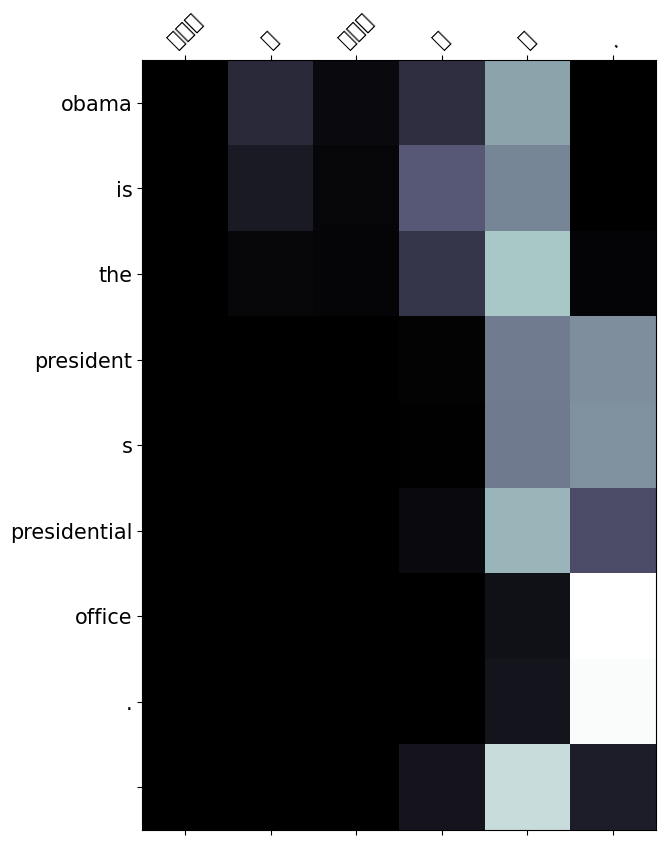

In [46]:
config = {
    "ko_path": "korean-english-park.train.ko",
    "en_path": "korean-english-park.train.en",
    "cache_file": "tokens_manual.pkl",    # hyper param
    "vocab_size": 10000,                        # hyper param 
    "emb_dim": 256,                             # hyper param
    "hid_dim": 512,                             # hyper param
    "epochs": 5,                                # hyper param
    "batch_size": 128,                          # hyper param
    "lr": 1e-3,                                 # hyper param
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}
test_cases = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]
nmt, kor_tok, eng_tok = run_experiment(config, test_cases)

nmt.visualize_attention(test_cases[0], kor_tok, eng_tok)

#### 실험 2 (Vocab 12000)

Loading cached tokens from tokens_manual.pkl...

Starting Training...


Epoch 1/5: 100%|██████████| 439/439 [02:56<00:00,  2.49it/s, loss=4.72]


Epoch 1 Loss: 5.3370
K1: obama is expected to be president barack obama s president , president bush said .
K2: they were also found in the <unk> of the <unk> river .
K3: the company was not immediately clear whether the company was not immediately clear .
K4: the taliban were killed in the attack , including the military junta , said the plane killed two people were killed .


Epoch 2/5: 100%|██████████| 439/439 [02:57<00:00,  2.48it/s, loss=4]   


Epoch 2 Loss: 4.2402
K1: obama is also a president of obama , who is president obama s president , obama said .
K2: the most powerful cities , the city s most famous <unk> , <unk> , <unk> , <unk> .
K3: i m not going to be able to make no matter or not to be able to make no matter .
K4: thousands of deaths have killed at least one of the deaths of the deaths .


...

Epoch 3 Loss: 3.5824
K1: obama is in the oval office , obama said .
K2: the victims were <unk> in the town of <unk> , the city s skyline .
K3: the money is no longer than the need for the first time , but it s not clear why .
K4: the death toll was killed in the deaths of the death toll , but killed one of the dead .


Epoch 4/5: 100%|██████████| 439/439 [02:57<00:00,  2.48it/s, loss=2.99]


Epoch 4 Loss: 3.0469
K1: obama is in the oval office , obama said .
K2: others are in the town of <unk> , <unk> . com .
K3: the caffeine is no need for the extension of coffee .
K4: the death toll was killed in the deaths of the death toll of the death toll of the death toll .


Epoch 5/5: 100%|██████████| 439/439 [02:57<00:00,  2.47it/s, loss=2.64]
/tmp/ipykernel_111/2800682502.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + src_tokens, rotation=45)
/tmp/ipykernel_111/2800682502.py:64: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + trg_tokens)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50724 (\N{HANGUL SYLLABLE O}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48148 (\N{HANGUL SYLLABLE BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47560 (\N{HANGUL SY

Epoch 5 Loss: 2.5971
K1: obama is now in the first black president , obama said tuesday .
K2: others are citizens in the city .
K3: the need for non governmental organizations is needed to be necessary , but no need for money .
K4: the death toll from the death toll is not a death toll .


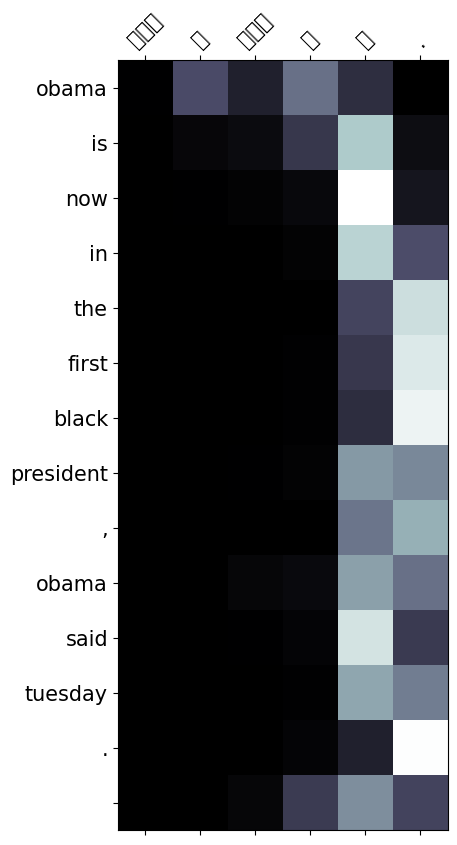

In [47]:
config = {
    "ko_path": "korean-english-park.train.ko",
    "en_path": "korean-english-park.train.en",
    "cache_file": "tokens_manual.pkl",    # hyper param
    "vocab_size": 12000,                        # hyper param 
    "emb_dim": 256,                             # hyper param
    "hid_dim": 512,                             # hyper param
    "epochs": 5,                                # hyper param
    "batch_size": 128,                          # hyper param
    "lr": 1e-3,                                 # hyper param
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu")
}
test_cases = ["오바마는 대통령이다.", "시민들은 도시 속에 산다.", "커피는 필요 없다.", "일곱 명의 사망자가 발생했다."]
nmt, kor_tok, eng_tok = run_experiment(config, test_cases)

nmt.visualize_attention(test_cases[0], kor_tok, eng_tok)